# Edge Factory OS — Strategy Evaluation Walkthrough

**Strategy:** `crypto_15m_idiosyncratic_sweep_short_trap_quality_time_exit_only`  
**Outcome:** Rejected — 84th percentile, below 95th percentile acceptance threshold

---

## 1. Strategy Hypothesis

This strategy targets **idiosyncratic liquidity sweeps** on 15-minute crypto perpetual futures.
The core idea: when a single asset briefly pierces a prior 48h high but immediately closes back below it
with a high upper wick — suggesting a stop-hunt or fake breakout — a short entry is taken.

### Signal stack (trap-quality filter, score ≥ 3/4)

| Component | Condition |
|---|---|
| Sweep depth | `(high − prior_high_48h) / ATR14 ≥ 0.15` |
| Upper wick share | `upper_wick / candle_range ≥ 0.40` |
| Close location | `(close − low) / candle_range ≤ 0.40` |
| Rejection depth | `(prior_high_48h − close) / ATR14 ≥ 0.05` |

A **market-pump veto** blocks entries during broad market surges (BTC/ETH 4h return > 1.5%, breadth > 35%).
Entries require an additional confirmation bar with minimum strength of 0.05 ATR.

### Single parameter changed from prior version

The postmortem on the prior strategy (`trap_quality_v1`) found that **time exits carried the edge** —
not take-profit exits. This version removes take-profit entirely.
Exit rule: **stop (sweep_high + 0.5 × ATR14) OR 8h time stop only.**
No other parameter was changed — this is a structural exit repair, not a grid search.

## 2. Pre-Registration Contract

In [1]:
import json
from pathlib import Path

REPO_ROOT = Path("..")

prereg_path = REPO_ROOT / "artifacts" / "research_preregistrations" / \
    "crypto_15m_idiosyncratic_sweep_short_trap_quality_time_exit_only_preregistration_v1.json"

with open(prereg_path) as f:
    prereg = json.load(f)

cfg = prereg["preregistered_config"]

print(f"Strategy   : {prereg['strategy']}")
print(f"Config ID  : {prereg['config_id']}")
print(f"Status     : {prereg['status']}")
print()
print("── Splits ──────────────────────────────────")
for split, dates in cfg["splits"].items():
    print(f"  {split:<12}: {dates[0][:10]}  →  {dates[1][:10]}")
print()
print("── Exit rule ───────────────────────────────")
exit_rule = cfg["exit_rule"]
print(f"  Stop          : {exit_rule['stop']}")
print(f"  Take-profit   : {exit_rule['take_profit']}")
print(f"  Time stop     : {exit_rule['time_stop_bars']} bars (= 8h on 15m)")
print()
print("── Only-changed parameter ──────────────────")
ocp = prereg["preregistered_config"]["only_changed_parameter"]
print(f"  Field         : {ocp['field']}")
print(f"  Prior value   : {ocp['prior_value']}")
print(f"  New value     : {ocp['new_value']}")
print(f"  Not a grid search: {ocp['not_a_grid_search']}")
print()
print("── Safety permissions (all False = pre-live) ─")
for k, v in prereg["safety_permissions"].items():
    print(f"  {k:<40}: {v}")

Strategy   : CRYPTO_15M_IDIOSYNCRATIC_SWEEP_SHORT_TRAP_QUALITY_TIME_EXIT_ONLY_V2
Config ID  : crypto_15m_idiosyncratic_sweep_short_trap_quality_time_exit_only_v2
Status     : PASS_REPO_ONLY_CRYPTO_15M_IDIOSYNCRATIC_SWEEP_SHORT_TRAP_QUALITY_TIME_EXIT_ONLY_PREREGISTRATION_CREATED

── Splits ──────────────────────────────────
  holdout     : 2025-04-01  →  2025-11-01
  train       : 2023-01-01  →  2024-07-01
  validation  : 2024-07-01  →  2025-04-01

── Exit rule ───────────────────────────────
  Stop          : sweep_high + 0.5 * ATR14
  Take-profit   : None
  Time stop     : 32 bars (= 8h on 15m)

── Only-changed parameter ──────────────────
  Field         : exit_rule
  Prior value   : stop OR take_profit OR time_exit
  New value     : stop OR time_exit only
  Not a grid search: True

── Safety permissions (all False = pre-live) ─
  candidate_generation_allowed_now        : False
  capital_permission_allowed_now          : False
  edge_claim_allowed_now                  : False
  famil

## 3. Execution Results

In [2]:
exec_path = REPO_ROOT / "artifacts" / "strategy_executions" / \
    "crypto_15m_idiosyncratic_sweep_short_trap_quality_time_exit_only_execution_v1.json"

with open(exec_path) as f:
    exec_data = json.load(f)

m = exec_data["metrics"]
sm = exec_data["split_metrics"]

print("── Full-period metrics ─────────────────────")
print(f"  Total closed trades  : {m['closed_trades']}")
print(f"  Exit rule            : {exec_data['exit_rule']}")
print(f"  Stop exits           : {m['stop_exit_count']}")
print(f"  Time exits           : {m['time_stop_exit_count']}")
print(f"  Take-profit exits    : {m['take_profit_exit_count']}")
print(f"  Max drawdown (bps)   : {m['max_drawdown_bps']:.1f}")
print()
print("── Validation split (2024-07-01 → 2025-04-01) ──")
val = sm["validation"]
print(f"  Closed trades        : {val['closed_trades']}")
print(f"  Net return (bps)     : {val['portfolio_net_bps']:.1f}")
print(f"  Monthly positive rate: {val['monthly_positive_rate']:.1%}")
print()
print("── Holdout split (2025-04-01 → 2025-11-01) ─────")
hold = sm["holdout"]
print(f"  Closed trades        : {hold['closed_trades']}")
print(f"  Net return (bps)     : {hold['portfolio_net_bps']:.1f}")
print(f"  Monthly positive rate: {hold['monthly_positive_rate']:.1%}")

── Full-period metrics ─────────────────────
  Total closed trades  : 454
  Exit rule            : {'no_take_profit_check': True, 'no_take_profit_order': True, 'stop': 'sweep_high + 0.5 * ATR14', 'take_profit': None, 'time_stop_bars': 32}
  Stop exits           : 176
  Time exits           : 278
  Take-profit exits    : 0
  Max drawdown (bps)   : -1253.8

── Validation split (2024-07-01 → 2025-04-01) ──
  Closed trades        : 94
  Net return (bps)     : 474.5
  Monthly positive rate: 55.6%

── Holdout split (2025-04-01 → 2025-11-01) ─────
  Closed trades        : 67
  Net return (bps)     : 760.2
  Monthly positive rate: 85.7%


## 4. Null-Baseline Test

A strong backtest result is **necessary but not sufficient**. Before any strategy can be accepted,
it must pass a null-baseline test: how likely is a result this good to arise by chance,
given that many strategies were tried?

**Method:** deterministic trade-PnL timestamp/block shuffle proxy — 100 runs.  
The observed validation PnL is ranked against 100 shuffled versions of the same trades.
The shuffle preserves trade structure but randomises timing, removing any genuine time-series edge.

**Acceptance threshold: 95th percentile** (i.e., the result must beat 95 of 100 null runs).

In [3]:
nb = exec_data["null_baseline"]

ACCEPTANCE_THRESHOLD = 0.95

print("── Null-baseline result ────────────────────")
print(f"  Method               : {nb['method']}")
print(f"  Runs                 : {nb['runs']}")
print(f"  Observed PnL (USDT)  : {nb['observed_validation_pnl_usdt']:.2f}")
print(f"  Validation percentile: {nb['validation_percentile']:.0%}  (= {nb['validation_percentile'] * 100:.0f}th percentile)")
print(f"  Acceptance threshold : {ACCEPTANCE_THRESHOLD:.0%}  (= 95th percentile)")
print(f"  Gap to threshold     : {(ACCEPTANCE_THRESHOLD - nb['validation_percentile']) * 100:.0f} percentile points")
print(f"  null_pass            : {nb['null_pass']}")
print()
if nb["null_pass"]:
    print("RESULT: PASS — strategy meets the null-baseline bar.")
else:
    print("RESULT: FAIL — strategy does NOT meet the null-baseline bar.")
    print(f"  The result (+474.5 bps validation) sits at the {nb['validation_percentile']:.0%} of the null "
          f"distribution — strong, but not rare enough (need ≥ 95th pct).")

── Null-baseline result ────────────────────
  Method               : deterministic trade-pnl timestamp/block shuffle proxy
  Runs                 : 100
  Observed PnL (USDT)  : 47.45
  Validation percentile: 84%  (= 84th percentile)
  Acceptance threshold : 95%  (= 95th percentile)
  Gap to threshold     : 11 percentile points
  null_pass            : False

RESULT: FAIL — strategy does NOT meet the null-baseline bar.
  The result (+474.5 bps validation) sits at the 84% of the null distribution — strong, but not rare enough (need ≥ 95th pct).


## 5. Percentile Position — Visual

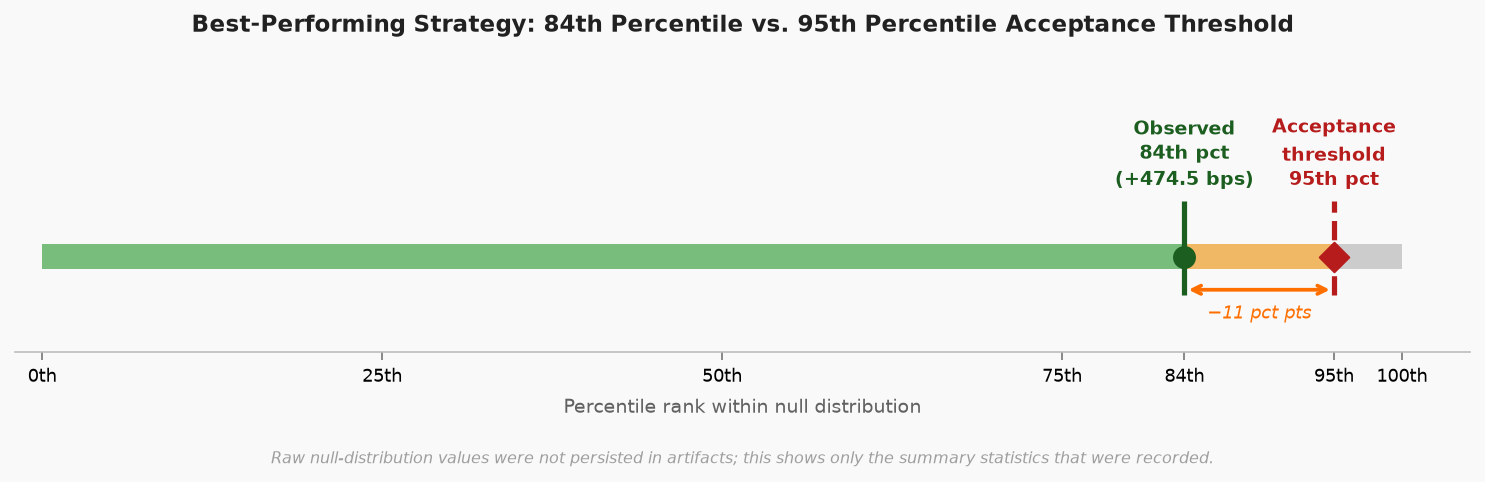


Note: raw null-distribution values were not persisted in artifacts;
this shows only the summary statistics that were recorded.


In [4]:
from IPython.display import Image, display

vis_path = REPO_ROOT / "artifacts" / "visualizations" / "percentile_threshold_example.png"
display(Image(filename=str(vis_path)))
print()
print("Note: raw null-distribution values were not persisted in artifacts;")
print("this shows only the summary statistics that were recorded.")

## 6. Conclusion — Why It Was Rejected

### The verdict

Despite being the **strongest candidate discovered across 33 evaluated strategies**,
`crypto_15m_idiosyncratic_sweep_short_trap_quality_time_exit_only` was **rejected**.

The numbers looked compelling:
- Validation: **+474.5 bps** across 94 trades, 55.6% of months positive
- Holdout: **+760.2 bps** across 67 trades, 85.7% of months positive
- 454 total trades across 80+ symbols — not a small-sample artefact

But the null-baseline test placed the result at the **84th percentile** — meaning
a result this strong can be produced ~16% of the time by chance shuffling alone.
The pipeline requires **≥ 95th percentile**. The gap: 11 percentile points.

### Why this discipline matters

When many strategies are tested, some will look good purely by luck.
A result at the 84th percentile sounds strong in isolation, but when you consider
that 33 strategies were evaluated, the probability that at least one of them
crosses the 84th percentile by chance is very high.

The 95th percentile bar — combined with pre-registration (hypothesis locked before
execution) and single-config-only constraints (no grid search, no parameter tuning) —
is what makes a surviving result meaningful.

### All 33 strategies were rejected

Every strategy evaluated in this project failed the null-baseline test.
Several showed double- or triple-digit apparent returns. All were rejected.
This is the correct outcome: the pipeline is working as designed.

> *A good-looking backtest is necessary but not sufficient.
> The null-baseline test is the gate that separates signal from noise.*